In [1]:
import torch
import numpy as np
import scipy
import pytorch_lightning as pl
from tqdm import tqdm
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
torch.set_float32_matmul_precision('medium')

# import multiprocessing
# multiprocessing.set_start_method('spawn')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os, sys
import plotfancy as pf

sys.path.append("../../mist-base")
sys.path.append('../../')

# from src.simulators.fd_simulators import GW_Additive_F, GW_Additive_F_Correlated

In [2]:
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal.windows import tukey
import jax
import jax.numpy as jnp
from astropy.time import Time
from ripple.waveforms import IMRPhenomD, IMRPhenomXAS
from jimgw.single_event.detector import H1, L1
from functools import partial
import sys

sys.path.append('../../mist-base/GW')
sys.path.append('../../')

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

defaults = {
    "approximant": "IMRPhenomD",
    "f_min": 20., #40.0,
    "f_max": 1024., #400.0,
    "f_ref": 20.0,
    "notches": [60.0, 120.0, 180.0],
    "notch_width": 0.1,
    "trigger_time": 1126259462.4,
    "pre_trigger_time": 2.0,
    "post_trigger_time": 2.0,
    "data_window": 1000,
    "psd_window":4,
    # "psd_pad": 16.0,
    "ifo": "H1",
    # "tukey_alpha": 0.2,
    "posterior_samples_path": "GW150814_posterior_samples.npz",
}

class Base_GW150914:
    def __init__(self, settings:dict={}, stoch_mu=True):
        self.settings = settings
        self.stoch = stoch_mu
        self._unpack_settings()
        self._initialise_gw()
        self._load_posterior_samples()
        self._setup_waveform()

    ### METHODS ###
    
    def _unpack_settings(self):
        self.approximant = self.settings.get("approximant", "IMRPhenomD")
        self.f_min = self.settings.get("f_min", 20.)
        self.f_max = self.settings.get("f_max", 1024.)
        self.f_ref = self.settings.get("f_ref", 20.0)
        self.notches = self.settings.get("notches", [60.0, 120.0, 180.0])
        self.notch_width = self.settings.get("notch_width", 0.1)
        self.trigger_time = self.settings.get("trigger_time", 1126259462.4)
        self.pre_trigger_time = self.settings.get("pre_trigger_time", 2.0)
        self.post_trigger_time = self.settings.get("post_trigger_time", 2.0)
        self.data_window = self.settings.get("data_window", 1000)
        self.psd_window = self.settings.get("psd_window", 10)
        # self.psd_pad = self.settings.get("psd_pad", 16.0)
        self.ifo = self.settings.get("ifo", "H1")
        # self.tukey_alpha = self.settings.get("tukey_alpha", 0.2) #### CHANGE THIS ####
        self.posterior_samples_path = self.settings.get(
            "posterior_samples_path", "../../mist-base/GW/GW150814_posterior_samples.npz"
        )
        self.key = jax.random.PRNGKey(42)

    def _initialise_gw(self):
        self.event_time = event_gps('GW150914')
        print(f'Fetching {self.data_window}s of data from {self.ifo}. Will take <4mins.')
        self.gwosc_data = TimeSeries.fetch_open_data(self.ifo, self.event_time-2*self.data_window, 
                                                     self.event_time-self.data_window, sample_rate=4096)
        print(f'Calculating PSD for FFT window length {self.psd_window}s.')
        self.psd = self.gwosc_data.psd(fftlength=self.psd_window)
        self.frequencies = self.psd.frequencies.value
        self.tukey_alpha = 1/self.psd_window

        self.times = self.gwosc_data.times.value - self.trigger_time
        self.duration = self.gwosc_data.duration.value
        self.npts = len(self.gwosc_data)
        self.delta_t = self.gwosc_data.dt.value
        # self.epoch = self.duration - self.post_trigger_time
        self.gmst = (
            Time(self.trigger_time, format="gps")
            .sidereal_time("apparent", "greenwich")
            .rad
        )
        if self.ifo == "H1":
            self.detector = H1
        elif self.ifo == "L1":
            self.detector = L1
        
    def _tukey(self, x):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        window = tukey(np.shape(x)[1], alpha=self.tukey_alpha) # shape [nbins]
        return x*np.expand_dims(window,axis=0) # shape [nsamples, nbins]
    
    # def _bandpass(self, x, range=None, f=None):
    #     freqs = self.frequencies if f==None else np.array(f)
    #     if range==None:
    #         return x
    #     else:
    #         mask = (freqs<range[0])&(freqs>range[1])
    #         x[...,mask] = 0
    #         return x

    # def setup_filter(self):
    #     bandpass = jnp.logical_and(
    #         self.frequencies > self.f_min, self.frequencies < self.f_max
    #     )
    #     notches = jnp.ones_like(self.frequencies)
    #     for notch in self.notches:
    #         notches = jnp.logical_and(
    #             notches,
    #             jnp.logical_or(
    #                 self.frequencies < notch - self.notch_width,
    #                 self.frequencies > notch + self.notch_width,
    #             ),
    #         )
    #     self.filter = jnp.logical_and(bandpass, notches)

    def _bandpass(self,x, range=None, f=None):
        freqs = self.frequencies if type(f)==type(None) else np.array(f)
        if range == None:
            return x
        else:
            x = jnp.array(x)
            f_min = range[0]
            f_max = range[1]
            bandpass = jnp.logical_and(
                freqs > f_min, freqs < f_max
            )
            notches = jnp.ones_like(freqs)
            for notch in self.notches:
                notches = jnp.logical_and(
                    notches,
                    jnp.logical_or(
                        freqs < notch - self.notch_width,
                        freqs > notch + self.notch_width,
                    ),
                )
            filter = jnp.logical_and(bandpass, notches)
            reshape_dims = (1,) * (x.ndim - 1) + (-1,)
            return x*jnp.reshape(filter,reshape_dims)

    
    def whiten(self, x, rl=True):
        # x is supplied in form [nbins (complex)]
        x = np.array(x)
        if rl:
            return np.abs(x/np.sqrt(self.psd.data))
        else:
            return x/np.sqrt(self.psd.data)
    
    def whiten_batch(self,x, rl=True):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        prefactor = np.expand_dims(np.sqrt(np.array(self.psd.data)), axis=0)
        if rl:
            return np.abs(x/prefactor)
        else:
            return x/prefactor
    
    def frequency_to_time_domain(self, x, bp_range=None, freqgrid=None):
        x = np.array(x)
        x = self._bandpass(x, range=bp_range, f=freqgrid) ### RETURNS X if bp_range == None 
        return jnp.fft.irfft(jnp.array(x), axis=-1) / self.delta_t
    
    def _load_posterior_samples(self):
        # print(f"Loading posterior samples from {self.posterior_samples_path}")
        self.posterior_samples = np.load(self.posterior_samples_path)
        self.parameter_names = [
            "M_c",
            "q",
            "s1_z",
            "s2_z",
            "d_L",
            "t_c",
            "phase_c",
            "iota",
            "ra",
            "dec",
            "psi",
        ]
        for param_name in self.posterior_samples.files:
            if param_name not in self.parameter_names:
                raise ValueError(
                    f"Parameter {param_name} not recognized in posterior file"
                )
        self.posterior_array = np.vstack(
            [self.posterior_samples[name] for name in self.parameter_names]
        ).T
        self.posterior_array[:, 1] = (self.posterior_array[:, 1]) / (
            1.0 + self.posterior_array[:, 1]
        ) ** 2  # q -> eta = q / (1 + q)^2
        # self.posterior_array[:, 5] = (
        #     self.epoch + self.posterior_array[:, 5]
        # )  # t_c -> t_c + epoch
        self.posterior_array[:, 5] = (
            self.psd_window / 2.0 + self.posterior_array[:, 5]
        ) # t_c -> t_c + epoch

    def _setup_waveform(self):
        if self.approximant == "IMRPhenomD":
            self.waveform = IMRPhenomD.gen_IMRPhenomD_hphc
        elif self.approximant == "IMRPhenomXAS":
            self.waveform = IMRPhenomXAS.gen_IMRPhenomXAS_hphc
        else:
            raise ValueError(f"Approximant {self.approximant} not recognized")
    
    ### DATA GETTERS ###

    def _get_noise_td(self, nsamples):
        ref = self.event_time-1.5*self.data_window
        nbins = len(self.gwosc_data.crop(ref-self.psd_window/2, ref+self.psd_window/2))
        alldata_raw = jnp.array(self.gwosc_data)
        max_start_index = alldata_raw.shape[0] - nbins
        start_indices = jax.random.randint(self.key, shape=(nsamples,), minval=0, maxval=max_start_index + 1)
        offsets = jnp.arange(nbins)
        indices = start_indices[:, None] + offsets
        return alldata_raw[indices]
    
    def get_noise_fd(self, nsamples, real=True):
        noise_td = self._get_noise_td(nsamples=nsamples)
        noise_td_windowed = self._tukey(noise_td)
        noise_fd_complex = jnp.fft.rfft(noise_td_windowed)*self.gwosc_data.dt
        return self.whiten_batch(noise_fd_complex, rl=real)
    
    def get_GW150914_td(self):
        return TimeSeries.fetch_open_data(self.ifo, self.trigger_time-self.psd_window/2, 
                                                     self.trigger_time+self.psd_window/2, sample_rate=4096)
        
    def get_GW150914_fd(self, real=True):
        raw = self.get_GW150914_td().data
        raw_windowed = np.squeeze(self._tukey(np.expand_dims(raw,axis=0)), axis=0)
        raw_fd = np.fft.rfft(raw_windowed)*self.gwosc_data.dt
        return self.whiten(raw_fd, rl=real)
        # return np.abs(raw_fd/np.sqrt(self.psd.data))
    
    ### WAVEFORM GENERATORS ###

    @partial(jax.jit, static_argnums=(0,))
    def call_waveform(self, theta_ripple):
        hp, hc = self.waveform(self.frequencies, theta_ripple, f_ref=self.f_ref)
        return hp, hc
    
    def _fd_theta_batched(self,nsims):
        if not self.stoch:
            choices = np.random.choice(self.posterior_array.shape[0], size=1, replace=True)
            single_param_set = self.posterior_array[choices]
            params_batch = np.tile(single_param_set, (nsims, 1))
            return torch.from_numpy(params_batch)
        else:
            choices = np.random.choice(self.posterior_array.shape[0], size=nsims, replace=True)
            params_batch = self.posterior_array[choices]
            return torch.from_numpy(params_batch)
        
    def _fd_waveform_batched_unwhitened(self, params_batch_tensor, grid=None):
        freqs = self.frequencies

        params_batch = params_batch_tensor.numpy()
        theta_ripple_batch = params_batch[:, :8]
        ra_batch, dec_batch, psi_batch = params_batch[:, 8], params_batch[:, 9], params_batch[:, 10]
        batched_waveform = jax.vmap(self.call_waveform)
        batched_detector_response = jax.vmap(
            self.detector.fd_response,
            in_axes=(None, {'p': 0, 'c': 0}, {'ra': 0, 'dec': 0, 'psi': 0, 'gmst': None})
        )
        hp_batch, hc_batch = batched_waveform(theta_ripple_batch)
        wf_fd_batch = batched_detector_response(
            freqs,
            {"p": hp_batch, "c": hc_batch},
            {"ra": ra_batch, "dec": dec_batch, "psi": psi_batch, "gmst": self.gmst},
        )
        # Instead of ``x[idx] = y``, use ``x = x.at[idx].set(y)
        wf_fd_batch = wf_fd_batch.at[np.isnan(wf_fd_batch)].set(0)
        return wf_fd_batch
    
    def _fd_waveform_batched(self, pbt, real=True):
        wf_fd_batch = self._fd_waveform_batched_unwhitened(pbt)
        return self.whiten_batch(wf_fd_batch, rl=real)

In [3]:
gw = Base_GW150914()

Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 10s.


In [5]:
params = gw._fd_theta_batched(6)

waveform_fdu = gw._fd_waveform_batched_unwhitened(params)
waveform_fd = gw._fd_waveform_batched(params, real=False)
waveform_tdu = gw.frequency_to_time_domain(waveform_fdu, bp_range=[10,300])[0]
waveform_td = gw.frequency_to_time_domain(waveform_fd, bp_range=[10,300])[0]

gw15_tdu = gw.get_GW150914_td()

gw15_td = gw.frequency_to_time_domain(gw.get_GW150914_fd(real=False), bp_range=[10,300])

True

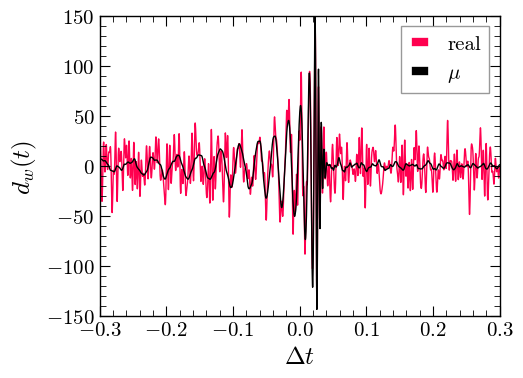

In [6]:
pf.housestyle_rcparams()
fig, ax = pf.create_plot()
time = np.linspace(-5,5,4096*10)
ax.plot(time,gw15_td, color='#ff004f', lw=1, label=r'real')
ax.plot(time,waveform_td, color='k',lw=1, label=r'$\mu$')
ax.legend()

ax.set_ylabel(r'$d_w(t)$')
ax.set_xlabel(r'$\Delta t$')

ax.set_xlim([-.3,.3])
ax.set_ylim([-150,150])
pf.fix_plot([ax])

In [7]:
samplerate =4096
delta_t=1/samplerate
data_window = 2000
bigdata = TimeSeries.fetch_open_data(gw.ifo, gw.trigger_time-data_window/2, 
                                                     gw.trigger_time+data_window/2, sample_rate=4096)

In [8]:
duration = 300
timegrid = np.linspace(-duration/2,duration/2, samplerate*duration)
smallf = jnp.arange(0,samplerate/2+1/duration, 1/duration)

def load_posterior(psd_window):
    posterior_samples = np.load(gw.posterior_samples_path)
    parameter_names = [
        "M_c",
        "q",
        "s1_z",
        "s2_z",
        "d_L",
        "t_c",
        "phase_c",
        "iota",
        "ra",
        "dec",
        "psi",
    ]
    for param_name in posterior_samples.files:
        if param_name not in parameter_names:
            raise ValueError(
                f"Parameter {param_name} not recognized in posterior file"
            )

    posterior_array = np.vstack(
        [posterior_samples[name] for name in parameter_names]
    ).T
    posterior_array[:, 1] = (posterior_array[:, 1]) / (
        1.0 + posterior_array[:, 1]
    ) ** 2  # q -> eta = q / (1 + q)^2
    # self.posterior_array[:, 5] = (
    #     self.epoch + self.posterior_array[:, 5]
    # )  # t_c -> t_c + epoch
    posterior_array[:, 5] = (
        psd_window / 2.0 + posterior_array[:, 5]
    ) # t_c -> t_c + epoch
    return posterior_array

def fd_theta_batched(nsims, psdWindow=gw.psd_window):
    posterior_array = load_posterior(psd_window=psdWindow)
    choices = np.random.choice(posterior_array.shape[0], size=nsims, replace=True)
    params_batch = posterior_array[choices]
    return torch.from_numpy(params_batch)

@partial(jax.jit, static_argnums=(0,))
def call_waveform(theta_ripple):
    hp, hc = gw.waveform(smallf, theta_ripple, f_ref=gw.f_ref)
    return hp, hc

def fd_waveform_batched_unwhitened(params_batch_tensor, grid=None):
    freqs = gw.frequencies if type(grid)==type(None) else grid

    params_batch = params_batch_tensor.numpy()
    theta_ripple_batch = params_batch[:, :8]
    ra_batch, dec_batch, psi_batch = params_batch[:, 8], params_batch[:, 9], params_batch[:, 10]
    batched_waveform = jax.vmap(call_waveform)
    batched_detector_response = jax.vmap(
        gw.detector.fd_response,
        in_axes=(None, {'p': 0, 'c': 0}, {'ra': 0, 'dec': 0, 'psi': 0, 'gmst': None})
    )
    hp_batch, hc_batch = batched_waveform(theta_ripple_batch)
    wf_fd_batch = batched_detector_response(
        freqs,
        {"p": hp_batch, "c": hc_batch},
        {"ra": ra_batch, "dec": dec_batch, "psi": psi_batch, "gmst": gw.gmst},
    )
    # Instead of ``x[idx] = y``, use ``x = x.at[idx].set(y)
    wf_fd_batch = wf_fd_batch.at[np.isnan(wf_fd_batch)].set(0)
    return wf_fd_batch

def frequency_to_time_domain( x, bp_range=None, freqgrid=None):
    x = np.array(x)
    # x = gw._bandpass(x, range=bp_range, f=freqgrid) ### RETURNS X if bp_range == None 
    return jnp.fft.irfft(jnp.array(x), axis=-1) / bigdata.dt

def extract_and_window_center(data_array:np.ndarray, sample_rate:float, 
                              total_duration:float, extract_duration:float)->np.ndarray:
     n_total_points = int(sample_rate * total_duration)
     n_extract_points = int(sample_rate * extract_duration)
     center_index = n_total_points // 2
     points_on_each_side = n_extract_points // 2
     start_index = center_index - points_on_each_side
     end_index = start_index + n_extract_points
     central_segment = data_array[start_index:end_index]
    #  tukey_alpha = 0.5/extract_duration
     tukey_alpha=0.25
     window = tukey(n_extract_points, alpha=tukey_alpha)
     return central_segment * window

/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.batching.BatchTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.batching.BatchTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


True

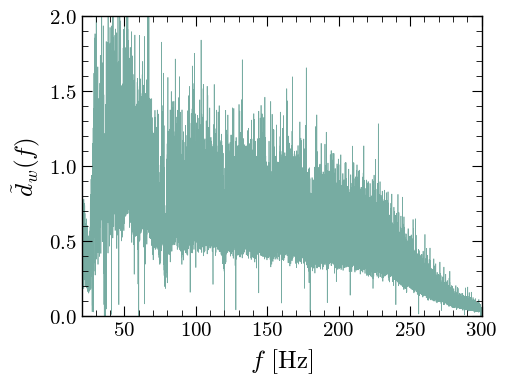

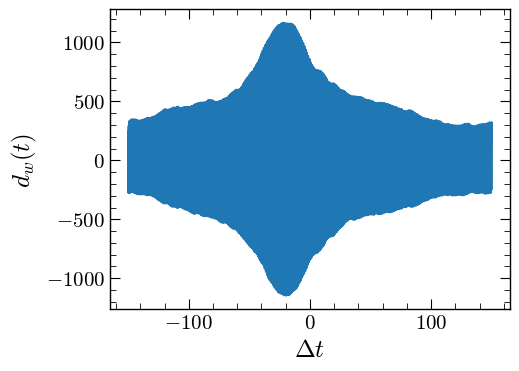

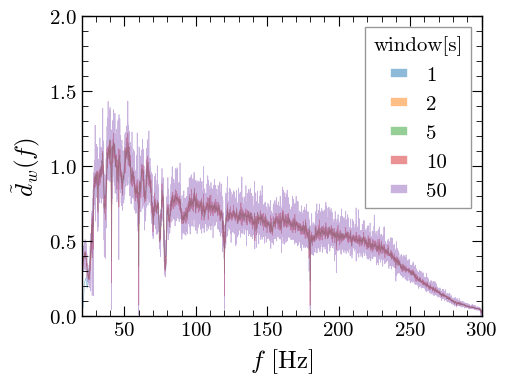

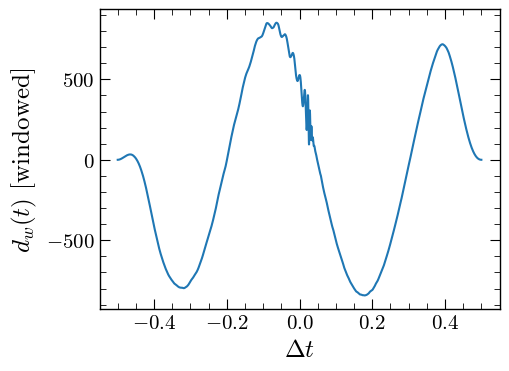

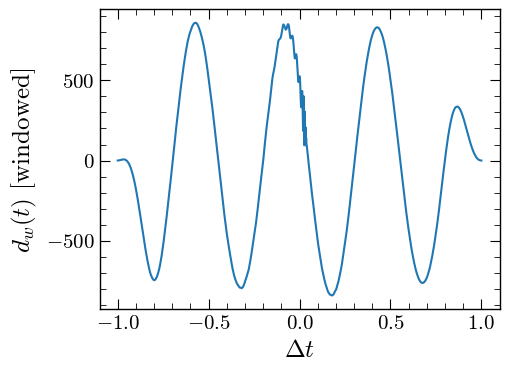

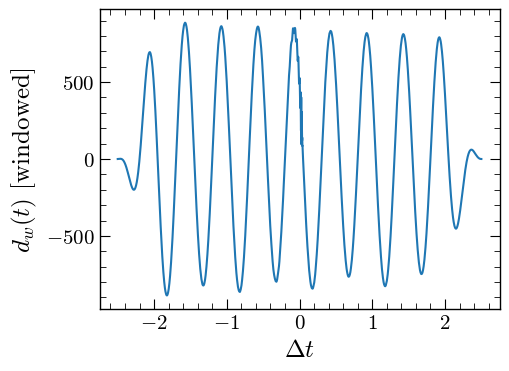

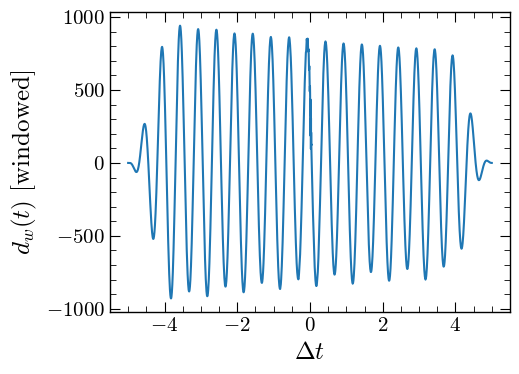

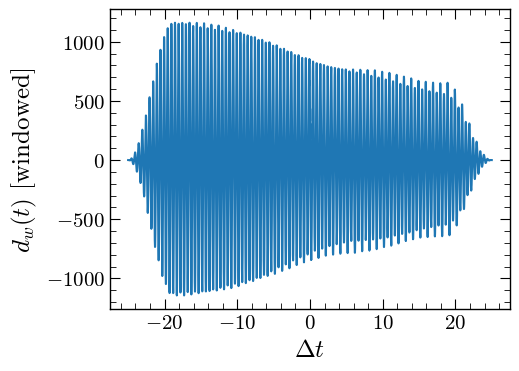

In [9]:
params = fd_theta_batched(6, psdWindow=duration)

wf_hdu = fd_waveform_batched_unwhitened(params, grid=smallf)
psd_local = bigdata.psd(fftlength=duration)
prefactor = np.expand_dims(np.sqrt(psd_local), axis=0)
wf_hd = wf_hdu/prefactor

axes=[]
fig,ax1 = pf.create_plot()
axes.append(ax1)
ax1.plot(smallf,np.abs(wf_hd[0]), linewidth=0.5, color='#77aca2')
ax1.set_ylim([0,2])
ax1.set_xlim(20,300)
ax1.set_ylabel(r'$\tilde{d}_w(f)$')
ax1.set_xlabel(r'$f$ [Hz]')

pf.fix_plot([ax1])

# wf_hd = gw._bandpass(wf_hd, range=[20,300], f=smallf) 
wf_td = np.fft.irfft(wf_hd)/delta_t

fig2,ax2 = pf.create_plot()
ax2.plot(timegrid,wf_td[0])
ax2.set_ylabel(r'$d_w(t)$')
ax2.set_xlabel(r'$\Delta t$')
axes.append(ax2)

windows = [1,2,5,10,50]
# colors = ['#ff004f',"#00ff77","#005eff","#ff00f2"]

fig,ax4 = pf.create_plot()
axes.append(ax4)
ax4.set_ylabel(r'$\tilde{d}_w(f)$')
ax4.set_xlabel(r'$f$ [Hz]')
ax4.set_ylim([0,2])
ax4.set_xlim(20,300)

for i,w in enumerate(windows):

    sample = wf_td[0]
    window_td = extract_and_window_center(sample,samplerate,duration,w)
    windowtime = np.linspace(-w/2,w/2, w*samplerate)
    # mask = ~np.isnan(window_td)
    # window_td = window_td*mask

    fig,ax3 = pf.create_plot()
    axes.append(ax3)
    ax3.plot(windowtime, window_td)
    ax3.set_ylabel(r'$d_w(t)$ [windowed]')
    ax3.set_xlabel(r'$\Delta t$')   

    window_fd = np.fft.rfft(window_td)*delta_t
    window_fd_freqs = np.fft.rfftfreq(len(window_td),delta_t)
    ax4.plot(window_fd_freqs,np.abs(window_fd), alpha=0.5, lw=0.5, label=w)

ax4.legend(title='window[s]') 
# ax4.plot(smallf,np.abs(wf_hd[0]), linewidth=0.5, color='#77aca2', zorder=-10) 

pf.fix_plot(axes)

In [ ]:
archive = np.load('gw1509data.npz')
gw1501914 = archive['gw150914']
f = archive['f']

fig,ax1 = pf.create_plot()
ax1.plot(f,gw1501914, color='#ff004f', label='real data')
ax1.plot(smallf,np.abs(wf_hd[0]), linewidth=0.5, color='k', alpha=0.5, label='whitened mu')
ax1.set_ylim([0,5])
ax1.set_xlim(20,800)
ax1.set_ylabel(r'$\tilde{d}_w(f)$')
ax1.set_xlabel(r'$f$ [Hz]')
ax1.legend()
pf.fix_plot([ax1])

In [ ]:
archive.keys